<a href="https://colab.research.google.com/github/amirkasaei/Intelligent-Analysis-of-Biomedical-Images/blob/main/HW/SPB_HW2/Prac/BrainMRI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import**

In [1]:
!pip install wandb -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 12.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.6/190.6 kB 13.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.0/241.0 kB 14.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 8.5 MB/s eta 0:00:00


In [2]:
import wandb
import os
import numpy as np
import seaborn as sns
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from skimage import io
import torch
import random
import pandas as pd
import glob
from sklearn.preprocessing import StandardScaler, normalize
import sklearn
from sklearn import metrics
from IPython.display import display
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import copy
import pickle
import torch.optim as optim
from torch.optim import lr_scheduler

# **Config**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
RANDOM_SEED = 42 # Must be used wherever can be used

torch.manual_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [6]:
wandb.login()
# 7f5c6eb77da002a218a74f8af39a66beeb83e891

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [7]:
wandb.init('BrainMRI')

wandb: Currently logged in as: amirkasaei. Use `wandb login --relogin` to force relogin


# **Preprocessing**

In [31]:
path = '/content/drive/MyDrive/AI/Deep Learning/SPB/HW2/'

In [32]:
classes = ['Ⅿeningioⅿa', 'Gⅼioⅿa', 'Pitutary']

In [33]:
phases = ['train', 'validation', 'test']
data = {}
for phase in phases:
  pickle_in = open(path+phase+".pickle","rb")
  data[phase] = np.array(pickle.load(pickle_in))
  data[phase][:, 1] -= 1

<ipython-input-33-1a0baecb341f>:5: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  data[phase] = np.array(pickle.load(pickle_in))


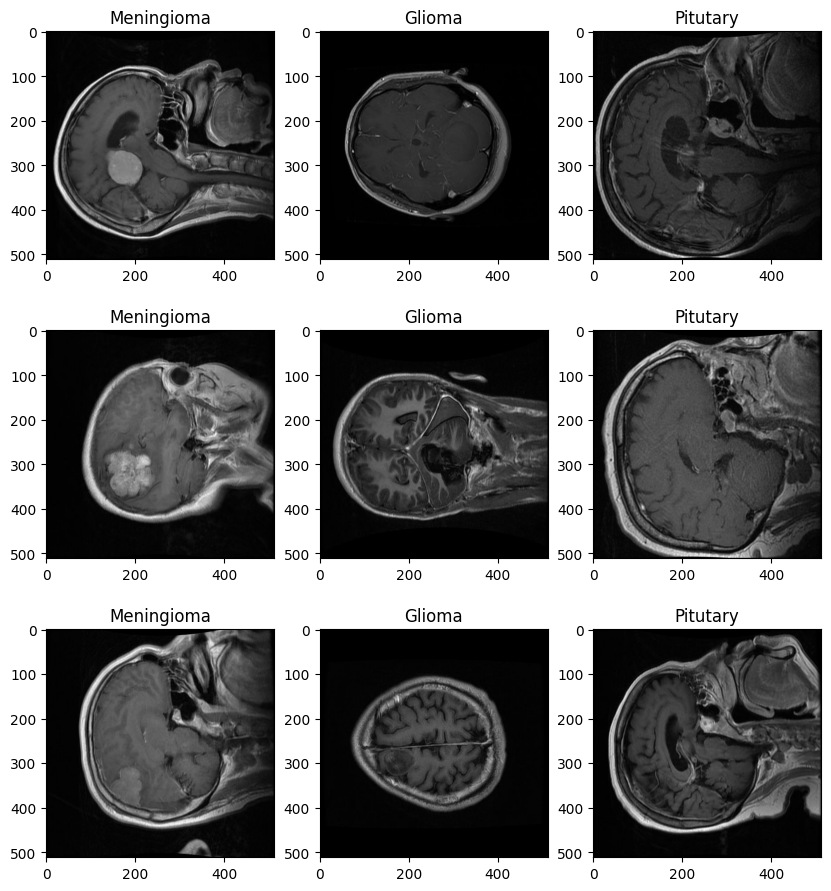

In [34]:
fig,axs = plt.subplots(3,3, figsize=(10,11))
for i in range(3):
    for j in range(3):
      idx = np.where(data['train'][:, 1] == j)[0]
      k = np.random.choice(idx)
      axs[i][j].title.set_text(classes[j])
      axs[i][j].imshow(data['train'][k][0])

In [35]:
class BrainMRIDataset(Dataset):
    def __init__(self, data, image_transform=None):
        self.data = data
        self.image_transform = image_transform

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        image = self.image_transform(self.data[idx][0])
        label = float(self.data[idx][1])

        return image, label


In [36]:
BATCH_SIZE = 64

train_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    # torchvision.transforms.Resize(227, interpolation=torchvision.transforms.InterpolationMode.BILINEAR,antialias=True),
])

test_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    # torchvision.transforms.Resize(227, interpolation=torchvision.transforms.InterpolationMode.BILINEAR,antialias=True),
])


train_dataset = BrainMRIDataset(
    data['train'],
    image_transform=train_transform,
)
val_dataest = BrainMRIDataset(
    data['validation'],
    image_transform=test_transform,
)
test_dataset = BrainMRIDataset(
    data['test'],
    image_transform=test_transform,
)

dataloaders = {}

dataloaders['train'] = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dataloaders['validation'] = DataLoader(val_dataest, batch_size=BATCH_SIZE, shuffle=False)
dataloaders['test'] = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# **Classification**

## **Helper Function**

In [61]:
def plot_confusionmatrix(y_train_pred,y_train, classes):
  print('Confusion matrix')
  cf = sklearn.metrics.confusion_matrix(y_train_pred,y_train)
  sns.heatmap(cf,annot=True,yticklabels=classes, xticklabels=classes, cmap='Blues', fmt='g')
  plt.tight_layout()
  plt.show()

In [62]:
def report(model, loader, device, classes):

  # Each epoch has a training and validation phase
  model.eval()   # Set model to evaluate mode

  y_pred = []
  y_true = []

  # Iterate over data.
  for inputs, labels in loader:
    inputs = inputs.to(device)
    labels = labels.type(torch.LongTensor)

    # forward
    # track history if only in train
    with torch.set_grad_enabled(False):
      outputs = model(inputs)
      _, preds = torch.max(outputs, 1)
      y_pred.extend(preds.cpu())
      y_true.extend(labels)

  plot_confusionmatrix(y_pred, y_true, classes)

In [63]:
def one_epoch(model, loader, criterion, optimizer, scheduler, device, phase):

  model.train()  # Set model to training mode

  running_loss = 0.0
  running_accuracy = 0.0
  running_precision = 0.0
  running_recall = 0.0
  running_f1_score = 0.0

  # Iterate over data.
  for inputs, labels in loader:
    inputs = inputs.to(device)
    labels = labels.type(torch.LongTensor).to(device)

    # zero the parameter gradients
    optimizer.zero_grad()

    # forward
    with torch.set_grad_enabled(phase == 'train'):
      outputs = model(inputs)
      _, preds = torch.max(outputs, 1)
      loss = criterion(outputs, labels)

      if phase == 'train':
        loss.backward()
        optimizer.step()

    # statistics
    running_loss += loss.item()
    running_accuracy += sklearn.metrics.accuracy_score(labels.cpu(), preds.cpu())
    running_precision += sklearn.metrics.precision_score(labels.cpu(), preds.cpu(), average='weighted', zero_division=0)
    running_recall += sklearn.metrics.recall_score(labels.cpu(), preds.cpu(), average='weighted', zero_division=0)
    running_f1_score += sklearn.metrics.f1_score(labels.cpu(), preds.cpu(), average='weighted', zero_division=0)

    # if phase == 'train' and not scheduler:
    #     scheduler.step()

  loss = running_loss / len(loader)
  accuracy = running_accuracy / len(loader)
  precision = running_precision / len(loader)
  recall = running_recall / len(loader)
  f1_score = running_f1_score / len(loader)

  return loss, accuracy, precision, recall, f1_score

In [81]:
def train(model, loaders, criterion, optimizer, num_epochs, device, scheduler=None):

  accuracy_dic, loss_dic = {}, {}
  loss_dic['train'], loss_dic['validation'] = [], []
  accuracy_dic['train'], accuracy_dic['validation'] = [], []

  for epoch in range(num_epochs):
      train_loss, train_acc, train_precision, train_recall, train_f1 = one_epoch(model, loaders['train'], criterion, optimizer, scheduler, device, phase='train' )
      val_loss, val_acc, val_precision, val_recall, val_f1 = one_epoch(model, loaders['validation'], criterion, optimizer, scheduler, device, phase='validation')

      loss_dic['train'].append(train_loss)
      loss_dic['validation'].append(val_loss)
      accuracy_dic['train'].append(train_acc)
      accuracy_dic['validation'].append(val_acc)

      print(f'Epoch [{epoch+1}/{num_epochs}] - '
            f'Train Loss: {train_loss:.4f} - '
            f'Train Accuracy: {train_acc:.4f} - '
            f'Validation Loss: {val_loss:.4f} - '
            f'Validation Accuracy {val_acc:.4f}% - '
            f'Validation Precisio {val_acc:.4f}% - '
            f'Validation Recall {val_acc:.4f}% - '
            f'Validation F1-score {val_acc:.4f}% ')

  return loss_dic, accuracy_dic

In [65]:
def evaluate(model, loaders, criterion, optimizer, device, phase, scheduler=None):

  loss, accuracy, precision, recall, f1_score = one_epoch(model, loaders[phase], criterion, optimizer, scheduler, device, phase)

  print(f'{phase} Loss: {loss:.4f} - '
        f'{phase} Acuracy {accuracy:.4f}% - '
        f'{phase} Precision: {precision:.4f}% - '
        f'{phase} Recall {recall:.4f}% - '
        f'{phase} F1: {f1_score:.2f}%')


In [87]:
def show_plots(num_epochs, data, metric):
  e = np.arange(num_epochs)
  plt.plot(e, data['train'], label='train '+metric)
  plt.plot(e, data['validation'], label='validation '+metric)
  plt.xlabel('epoch')
  plt.ylabel(metric)
  plt.legend()

## **From Scratch**

### **Implementation**

In [66]:
class AlexNet(nn.Module):
    def __init__(self ):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, 3),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [67]:
model_sc = AlexNet()
model_sc.to(device)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

### **Train**

In [68]:
lr = 1e-4
num_epochs = 50

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_sc.parameters()), lr=lr)
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
loss_dic, accuracy_dic = train(model_sc, dataloaders, criterion, optimizer, num_epochs, device)

Epoch [1/50] - Train Loss: 0.9421 - Train Accuracy: 0.5500 - Validation Loss: 0.8088 - Validation Accuracy 0.6254% - Validation Precisio 0.6254% - Validation Recall 0.6254% - Validation F1-score 0.6254% 
Epoch [2/50] - Train Loss: 0.7036 - Train Accuracy: 0.6787 - Validation Loss: 0.6890 - Validation Accuracy 0.6646% - Validation Precisio 0.6646% - Validation Recall 0.6646% - Validation F1-score 0.6646% 
Epoch [3/50] - Train Loss: 0.6042 - Train Accuracy: 0.7184 - Validation Loss: 0.6218 - Validation Accuracy 0.6771% - Validation Precisio 0.6771% - Validation Recall 0.6771% - Validation F1-score 0.6771% 
Epoch [4/50] - Train Loss: 0.5528 - Train Accuracy: 0.7348 - Validation Loss: 0.6189 - Validation Accuracy 0.7101% - Validation Precisio 0.7101% - Validation Recall 0.7101% - Validation F1-score 0.7101% 
Epoch [5/50] - Train Loss: 0.5315 - Train Accuracy: 0.7533 - Validation Loss: 0.5835 - Validation Accuracy 0.7364% - Validation Precisio 0.7364% - Validation Recall 0.7364% - Validatio

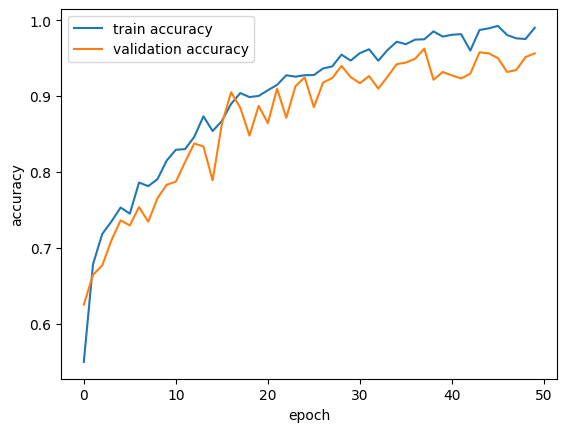

In [86]:
show_plots(num_epochs, accuracy_dic, 'accuracy')

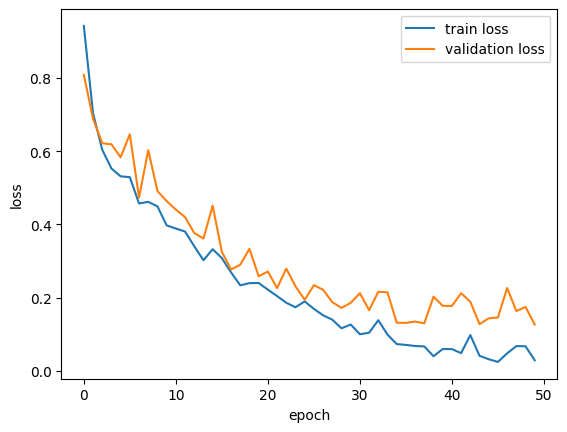

In [88]:
show_plots(num_epochs, loss_dic, 'loss')

### **Evaluation**

#### **Train**

In [71]:
evaluate(model_sc, dataloaders, criterion, optimizer, device, 'train')

train Loss: 0.0241 - train Acuracy 0.9908% - train Precision: 0.9914% - train Recall 0.9908% - train F1: 0.99%


Confusion matrix


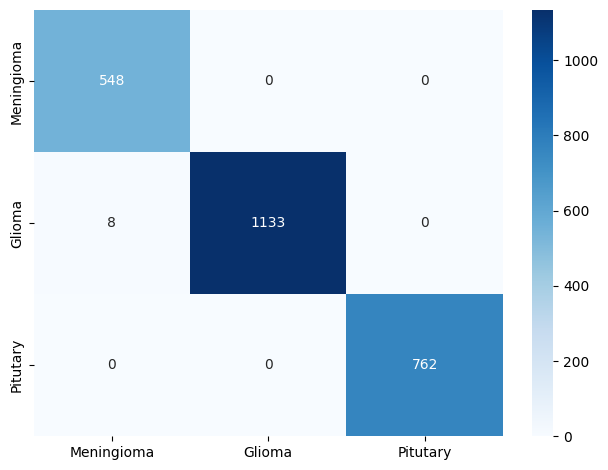

In [72]:
report(model_sc, dataloaders['train'], device, classes)

#### **Validation**

In [73]:
evaluate(model_sc, dataloaders, criterion, optimizer, device, 'validation')

validation Loss: 0.1686 - validation Acuracy 0.9491% - validation Precision: 0.9514% - validation Recall 0.9491% - validation F1: 0.95%


Confusion matrix


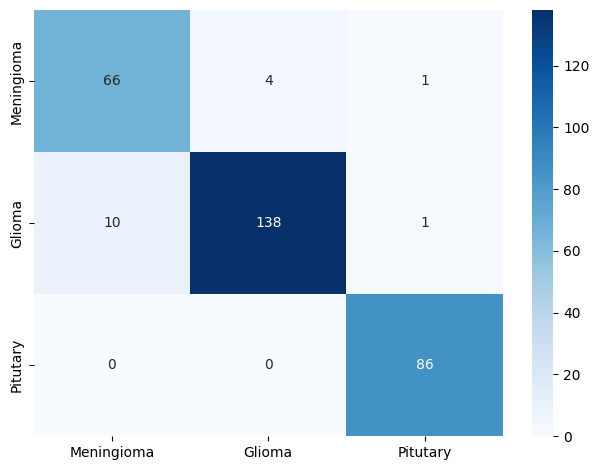

In [74]:
report(model_sc, dataloaders['validation'], device, classes)

#### **Test**

In [75]:
evaluate(model_sc, dataloaders, criterion, optimizer, device, 'test')

test Loss: 0.1743 - test Acuracy 0.9297% - test Precision: 0.9321% - test Recall 0.9297% - test F1: 0.93%


Confusion matrix


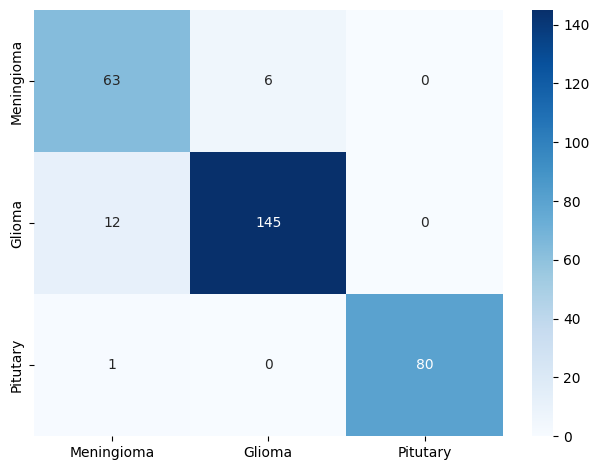

In [76]:
report(model_sc, dataloaders['test'], device, classes)

## **Pretrained**

### **Implementation**

In [93]:
model_pt = torchvision.models.alexnet(pretrained=True)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [94]:
input_features = model_pt.classifier[-1].in_features
model_pt.classifier[-1] = nn.Linear(in_features=input_features, out_features=3, bias=True)
# model_pt.classifier =nn.Sequential(
#             nn.Dropout(p=0.5),
#             nn.Linear(256 * 6 * 6, 4096),
#             nn.ReLU(inplace=True),
#             nn.Dropout(p=0.5),
#             nn.Linear(4096, 4096),
#             nn.ReLU(inplace=True),
#             nn.Linear(4096, 3),)
model_pt.to(device)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [95]:
for param in model_pt.features.parameters():
    param.require_grad = False

### **Train**

In [96]:
lr = 1e-4
num_epochs = 10

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_pt.parameters()), lr=lr)
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
loss_dic, accuracy_dic = train(model_pt, dataloaders, criterion, optimizer, num_epochs, device)

Epoch [1/10] - Train Loss: 0.5529 - Train Accuracy: 0.7613 - Validation Loss: 0.4575 - Validation Accuracy 0.7895% - Validation Precisio 0.7895% - Validation Recall 0.7895% - Validation F1-score 0.7895% 
Epoch [2/10] - Train Loss: 0.2640 - Train Accuracy: 0.8872 - Validation Loss: 0.2600 - Validation Accuracy 0.8845% - Validation Precisio 0.8845% - Validation Recall 0.8845% - Validation F1-score 0.8845% 
Epoch [3/10] - Train Loss: 0.2132 - Train Accuracy: 0.9118 - Validation Loss: 0.2147 - Validation Accuracy 0.9099% - Validation Precisio 0.9099% - Validation Recall 0.9099% - Validation F1-score 0.9099% 
Epoch [4/10] - Train Loss: 0.1631 - Train Accuracy: 0.9366 - Validation Loss: 0.1841 - Validation Accuracy 0.9036% - Validation Precisio 0.9036% - Validation Recall 0.9036% - Validation F1-score 0.9036% 
Epoch [5/10] - Train Loss: 0.1007 - Train Accuracy: 0.9636 - Validation Loss: 0.2263 - Validation Accuracy 0.8947% - Validation Precisio 0.8947% - Validation Recall 0.8947% - Validatio

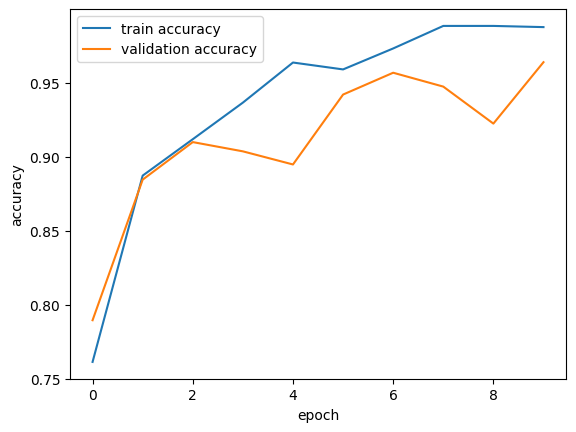

In [97]:
show_plots(num_epochs, accuracy_dic, 'accuracy')

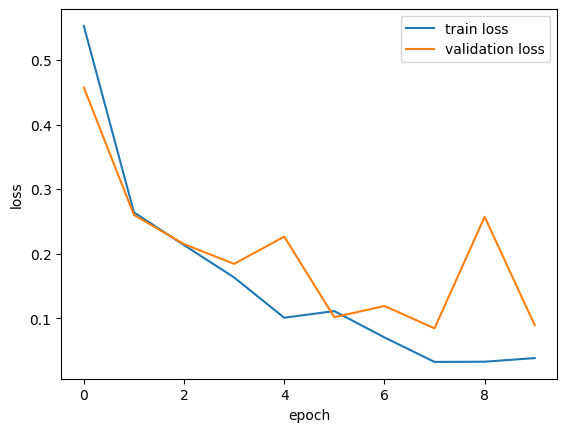

In [98]:
show_plots(num_epochs, loss_dic, 'loss')

### **Evaluation**

#### **Train**

In [99]:
evaluate(model_pt, dataloaders, criterion, optimizer, device, 'train')

train Loss: 0.0221 - train Acuracy 0.9920% - train Precision: 0.9928% - train Recall 0.9920% - train F1: 0.99%


Confusion matrix


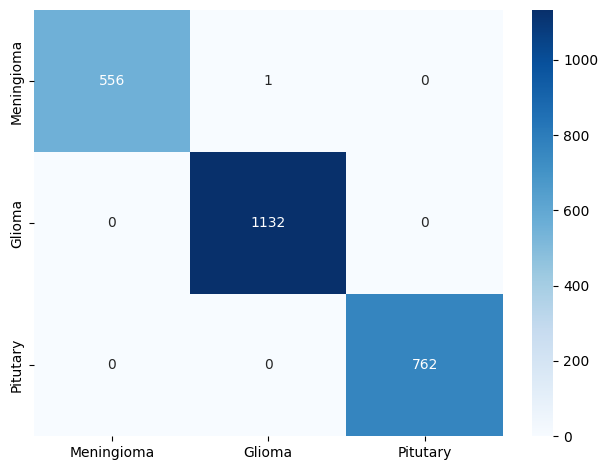

In [100]:
report(model_pt, dataloaders['train'], device, classes)

#### **Validation**

In [101]:
evaluate(model_pt, dataloaders, criterion, optimizer, device, 'validation')

validation Loss: 0.0894 - validation Acuracy 0.9661% - validation Precision: 0.9684% - validation Recall 0.9661% - validation F1: 0.97%


Confusion matrix


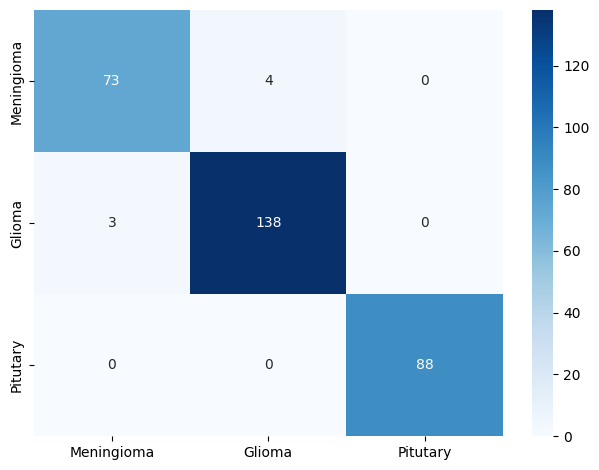

In [102]:
report(model_pt, dataloaders['validation'], device, classes)

#### **Test**

In [103]:
evaluate(model_pt, dataloaders, criterion, optimizer, device, 'test')

test Loss: 0.0750 - test Acuracy 0.9711% - test Precision: 0.9723% - test Recall 0.9711% - test F1: 0.97%


Confusion matrix


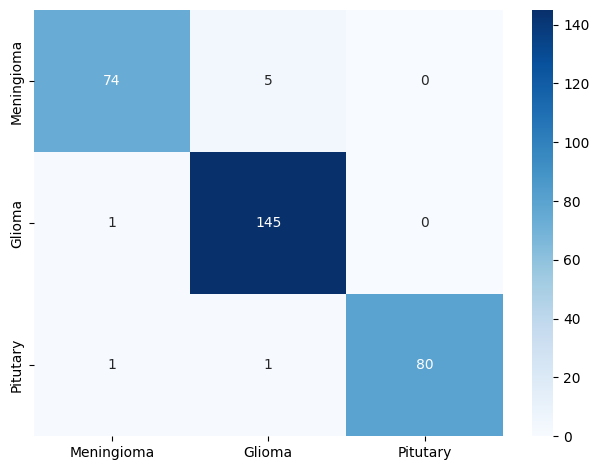

In [104]:
report(model_pt, dataloaders['test'], device, classes)

# **Refrences**

- [Torchvision](https://github.com/pytorch/vision/blob/main/torchvision/models/alexnet.py)